# VAE Training — Pipeline v2 (WINDOW_SIZE=60 data, same validated hyperparameters)

**Why no fresh beta/latent-dim search here**: the v1 pipeline's
`train_vae.ipynb` searched `beta_max` over {1.0, 0.1, 0.01, 0.001} and
`latent_dim` over {8, 16, 32}, landing on `beta_max=0.01, latent_dim=32`.
Two later, methodologically-corrected hyperparameter searches
(`experiments/hyperparameter_tuning.ipynb`, `hyperparameter_tuning_v2.ipynb`)
each tried to find something better than this — both made results *worse*,
for two distinct, well-understood reasons (see those notebooks). Combined
with a 5-seed check that showed this configuration's oracle ceiling is stable
across random initialization, there is strong, convergent evidence this is
already a genuine optimum for this architecture family, not a value worth
re-searching every time an input representation changes.

**What changed here**: only the training DATA (`windows_cc1_v2`, built from
60-step windows instead of 30-step) — `hidden1=64`, `hidden2=32`,
`latent_dim=32`, `beta_max=0.01` are identical to the deployed v1 model.
This isolates the window-size effect cleanly, per
`experiments/window_size_ablation.ipynb`'s original methodology.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pickle, os, time

torch.manual_seed(42)
np.random.seed(42)

BASE       = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1_v2')
MODEL_DIR  = os.path.join(BASE, 'models_v2')
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')

SPLITS = ['cc1_train', 'cc1_val', 'cc1_test', 'drift_cc2']

HIDDEN1        = 64
HIDDEN2        = 32
LATENT_DIM     = 32     # carried over from v1 (validated, not re-searched — see markdown above)
BETA_MAX       = 0.01   # carried over from v1
WARMUP_EPOCHS    = 10
FULL_MAX_EPOCHS  = 300
FULL_PATIENCE    = 20
LR               = 1e-3
BATCH_SIZE       = 512
CLIP             = 20.0

print('Hyperparameters configured (carried over from the validated v1 model).')

PyTorch 2.8.0+cpu  |  Device: cpu
Hyperparameters configured (carried over from the validated v1 model).


## Step 1 — Load data + sanity guard

In [2]:
raw = {name: np.load(os.path.join(DATA_DIR, f'X_{name}.npy')) for name in SPLITS}
labels = {name: np.load(os.path.join(DATA_DIR, f'y_{name}.npy')) for name in SPLITS}

INPUT_DIM = raw['cc1_train'].shape[1]
print(f'INPUT_DIM = {INPUT_DIM}')

for name, X in raw.items():
    assert X.shape[1] == INPUT_DIM, f'{name}: dim mismatch {X.shape[1]} != {INPUT_DIM}'
    assert not np.isnan(X).any(), f'{name}: contains NaN'
    assert not np.isinf(X).any(), f'{name}: contains Inf'
assert (labels['cc1_train'] == 0).all(), 'cc1_train contains labeled anomalies — training set must be normal-only'
print('Sanity checks passed: consistent dims, no NaN/Inf, cc1_train is 100% normal.')

data = {name: np.clip(X, -CLIP, CLIP).astype(np.float32) for name, X in raw.items()}

X_train_t = torch.from_numpy(data['cc1_train'])
X_val_t   = torch.from_numpy(data['cc1_val'])
print(f'X_train : {X_train_t.shape}   X_val : {X_val_t.shape}')

INPUT_DIM = 48
Sanity checks passed: consistent dims, no NaN/Inf, cc1_train is 100% normal.
X_train : torch.Size([152456, 48])   X_val : torch.Size([20763, 48])


## Step 2 — VAE class (identical to v1)

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2), nn.ReLU(),
            nn.Linear(hidden2, hidden1),    nn.ReLU(),
            nn.Linear(hidden1, input_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_lv(h), -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval()
        mu, _ = self.encode(x)
        recon = self.decode(mu)
        return ((recon - x) ** 2).mean(dim=1)


def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon_loss + beta * kl, recon_loss, kl

print('VAE class defined.')

VAE class defined.


## Step 3 — Full training (300 epochs, early stopping, `latent_dim=32`, `beta_max=0.01`)

In [4]:
def train_vae(latent_dim, max_epochs, patience, beta_max, verbose=False):
    torch.manual_seed(42)
    model = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_recon', 'val_recon', 'train_kl', 'val_kl']}
    best_val, best_state, patience_ctr = float('inf'), None, 0

    for epoch in range(max_epochs):
        beta = min(1.0, (epoch + 1) / WARMUP_EPOCHS) * beta_max
        model.train()
        tr_loss = tr_recon = tr_kl = 0.0
        n = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, rloss, kl = vae_loss(recon, xb, mu, logvar, beta)
            loss.backward()
            opt.step()
            bs = xb.size(0)
            tr_loss += loss.item() * bs; tr_recon += rloss.item() * bs; tr_kl += kl.item() * bs; n += bs
        tr_loss /= n; tr_recon /= n; tr_kl /= n

        model.eval()
        with torch.no_grad():
            xv = X_val_t.to(DEVICE)
            recon, mu, logvar = model(xv)
            vloss, vrecon, vkl = vae_loss(recon, xv, mu, logvar, beta)

        history['train_loss'].append(tr_loss);   history['val_loss'].append(vloss.item())
        history['train_recon'].append(tr_recon); history['val_recon'].append(vrecon.item())
        history['train_kl'].append(tr_kl);        history['val_kl'].append(vkl.item())

        if vloss.item() < best_val - 1e-6:
            best_val, best_state, patience_ctr = vloss.item(), {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose:
                    print(f'    early stop at epoch {epoch + 1} (best val_loss={best_val:.4f})')
                break

        if verbose and (epoch % 20 == 0 or epoch == max_epochs - 1):
            print(f'    epoch {epoch + 1:3d}  beta={beta:.4f}  '
                  f'train={tr_loss:.4f} (recon={tr_recon:.4f} kl={tr_kl:.4f})  val={vloss.item():.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val

print(f'Training final VAE: latent_dim={LATENT_DIM}, beta_max={BETA_MAX} ...')
t0 = time.time()
model, history, best_val = train_vae(LATENT_DIM, FULL_MAX_EPOCHS, FULL_PATIENCE, beta_max=BETA_MAX, verbose=True)
elapsed = time.time() - t0
print(f'\nDone in {elapsed/60:.1f} min.  Final best val loss: {best_val:.4f}  |  epochs run: {len(history["train_loss"])}')
final_kl = history['train_kl'][-1]
print(f'Final train KL: {final_kl:.4f}  ({"WARNING: looks collapsed" if final_kl < 0.05 else "non-trivial, ok"})')

Training final VAE: latent_dim=32, beta_max=0.01 ...
    epoch   1  beta=0.0010  train=1.4496 (recon=1.4229 kl=26.7841)  val=1.1076
    epoch  21  beta=0.0100  train=0.6834 (recon=0.5673 kl=11.6159)  val=0.7321
    epoch  41  beta=0.0100  train=0.5990 (recon=0.4677 kl=13.1350)  val=0.6494
    epoch  61  beta=0.0100  train=0.5727 (recon=0.4340 kl=13.8706)  val=0.6205
    epoch  81  beta=0.0100  train=0.5574 (recon=0.4160 kl=14.1468)  val=0.6047
    epoch 101  beta=0.0100  train=0.5460 (recon=0.4023 kl=14.3707)  val=0.5922
    epoch 121  beta=0.0100  train=0.5368 (recon=0.3907 kl=14.6110)  val=0.5824
    epoch 141  beta=0.0100  train=0.5305 (recon=0.3823 kl=14.8205)  val=0.5748
    epoch 161  beta=0.0100  train=0.5230 (recon=0.3721 kl=15.0919)  val=0.5660
    epoch 181  beta=0.0100  train=0.5159 (recon=0.3623 kl=15.3643)  val=0.5568
    epoch 201  beta=0.0100  train=0.5110 (recon=0.3559 kl=15.5051)  val=0.5514
    epoch 221  beta=0.0100  train=0.5073 (recon=0.3513 kl=15.6029)  val=0.5475

## Step 4 — Training curves

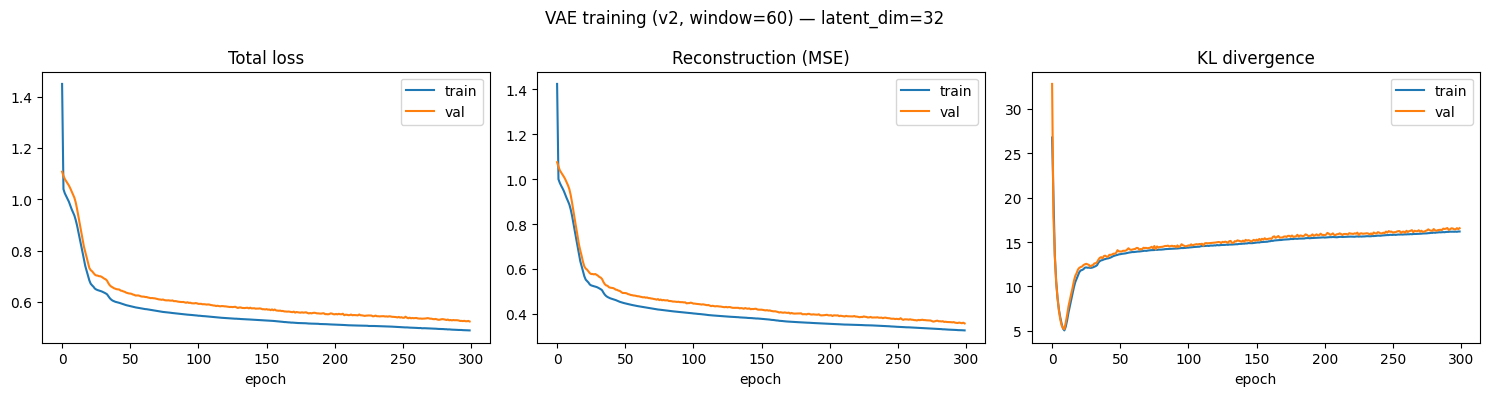

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['train_loss', 'train_recon', 'train_kl'],
                           ['Total loss', 'Reconstruction (MSE)', 'KL divergence']):
    ax.plot(history[key], label='train')
    ax.plot(history[key.replace('train', 'val')], label='val')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
plt.suptitle(f'VAE training (v2, window=60) — latent_dim={LATENT_DIM}')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_training_curves.png'), dpi=120)
plt.show()

## Step 5 — Train-MSE baseline

In [6]:
with torch.no_grad():
    mse_train = model.anomaly_score(X_train_t.to(DEVICE)).cpu().numpy()
    mse_val   = model.anomaly_score(X_val_t.to(DEVICE)).cpu().numpy()

mu_train, sigma_train = float(mse_train.mean()), float(mse_train.std())
print(f'cc1_train MSE: mean={mu_train:.5f}  std={sigma_train:.5f}')
print(f'cc1_val   MSE: mean={mse_val.mean():.5f}  std={mse_val.std():.5f}  (should be close to train — both normal)')

cc1_train MSE: mean=0.28407  std=0.24760
cc1_val   MSE: mean=0.31567  std=0.33181  (should be close to train — both normal)


## Step 6 — Directional sanity check

In [7]:
print(f'{"set":12s} {"normal_mean_mse":>16s} {"anomaly_mean_mse":>17s} {"ratio":>8s}')
for name in ['cc1_test', 'drift_cc2']:
    X = torch.from_numpy(data[name]).to(DEVICE)
    y = labels[name]
    with torch.no_grad():
        mse = model.anomaly_score(X).cpu().numpy()
    normal_mse = mse[y == 0].mean()
    anom_mse   = mse[y == 1].mean() if (y == 1).any() else float('nan')
    ratio = anom_mse / normal_mse if normal_mse > 0 else float('nan')
    print(f'{name:12s} {normal_mse:16.5f} {anom_mse:17.5f} {ratio:8.2f}x')

set           normal_mean_mse  anomaly_mean_mse    ratio
cc1_test              0.26866          10.35929    38.56x
drift_cc2             0.88753           6.45652     7.27x


## Step 7 — Save model + baseline stats

In [8]:
model_path = os.path.join(MODEL_DIR, 'vae_cc1.pt')
torch.save(model.state_dict(), model_path)

meta = {
    'input_dim':   INPUT_DIM,
    'hidden1':     HIDDEN1,
    'hidden2':     HIDDEN2,
    'latent_dim':  LATENT_DIM,
    'beta_max':    BETA_MAX,
    'clip':        CLIP,
    'window_size': 60,
    'mu_train':    mu_train,
    'sigma_train': sigma_train,
}
meta_path = os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)

print(f'Model saved -> {model_path}')
print(f'Metadata saved -> {meta_path}')
print(f'\n{meta}')

Model saved -> c:\Users\jthar\Documents\Claude\Projects\module3\module3\models_v2\vae_cc1.pt
Metadata saved -> c:\Users\jthar\Documents\Claude\Projects\module3\module3\models_v2\vae_cc1_meta.pkl

{'input_dim': 48, 'hidden1': 64, 'hidden2': 32, 'latent_dim': 32, 'beta_max': 0.01, 'clip': 20.0, 'window_size': 60, 'mu_train': 0.28406664729118347, 'sigma_train': 0.24759788811206818}


## Output files

| File | Contents |
|---|---|
| `models_v2/vae_cc1.pt` | trained VAE state_dict (window=60 data, `latent_dim=32`) |
| `models_v2/vae_cc1_meta.pkl` | architecture config, `clip`, `window_size`, `mu_train`, `sigma_train` |
| `models_v2/vae_cc1_training_curves.png` | train/val loss, reconstruction, KL curves |

**Next:** `vae_eval.ipynb` (v2) — full metrics suite, identical protocol to v1.